In [1]:
%load_ext autoreload
%autoreload 2

# Fiducial vs epsilon-scaled orbits: z=0 comparison

Compares the fiducial (no orbit perturbation) and epsilon-scaled-orbit
merger-tree samples for the 13.0 mass bin, produced by
`SatGen/notebooks/claude_based/epsilon_ratio_orbit_init.py` (the epsilon
perturbation) and `MassSpec/src/epsilon_orbits/run_abundance.py` (the
abundance measurements -> `fiducial.h5` and `epsilon.h5`).

Modeled after `MassSpec/notebooks/paper3/satgen_bolshoi.ipynb`'s
`plot_corner_with_corr` comparison, adapted for two SatGen samples (rather
than SatGen vs Bolshoi) and generalized to take an arbitrary pair of
model labels/suffixes.

In [2]:
import itertools
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_stats

In [3]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0  # inches
single_textwidth = 3.5  # inches
levelz = [1 - 0.99, 1 - 0.95, 1 - 0.68]  # contour levels, matches satgen_bolshoi.ipynb

In [4]:
epsilon_df = pd.read_csv("../../data/epsilon/epsilon_z0.csv")

fiducial_df = pd.read_csv("../../data/epsilon/fiducial_z0.csv")

## Corner plot: fiducial vs epsilon

Same panel layout as `satgen_bolshoi.ipynb`'s `plot_corner_with_corr`
(diagonal = 1D KDE marginals, lower triangle = 2D KDE contours + Spearman
$\rho$ annotated per model), generalized to take an arbitrary list of
`(suffix, label)` models instead of hardcoded SatGen/Bolshoi. `logMvir` is
left out of the panel keys since both samples are the single 13.0 mass
bin (no spread to show).

The two models are paired by `tree_index` (an inner merge) rather than by
mass bin like the SatGen-vs-Bolshoi comparison -- `epsilon.h5` and
`fiducial.h5` are the *same* underlying trees, just with/without the
orbit perturbation, so pairing on `tree_index` compares each tree to
itself across the two runs (and naturally drops any tree that errored out
in one run but not the other).

In [9]:
def plot_corner_with_corr(matched, models, keys, paramNames, colors=("steelblue", "darkorange"),
                           paramRanges=None, figsize=14):
    """
    Corner comparison between two models using a matched dataframe, with
    Spearman correlation coefficients annotated in each off-diagonal panel.

    models : list of (suffix, label) tuples, e.g. [("fid", "fiducial"), ("eps", "epsilon")]
    keys   : column base-names to compare, expected in matched as f"{key}_{suffix}"
    paramRanges : list of [lo, hi] per key, or None to auto-range from the data (1st/99th percentile + 5% pad)
    """

    model_colors = dict(zip([m for _, m in models], colors))

    model_chains = {}
    model_rho = {}

    for suffix, model in models:
        cols = [f"{k}_{suffix}" for k in keys]
        chain = matched[cols].copy()
        chain.columns = keys

        mask = ~chain.isna().any(axis=1)
        chain = chain.loc[mask].reset_index(drop=True)

        pair_rho = {}
        for k1, k2 in itertools.combinations(keys, 2):
            pair_rho[(k1, k2)] = jsm_stats.correlation(chain[k1].values, chain[k2].values)

        model_chains[model] = chain
        model_rho[model] = pair_rho

    if paramRanges is None:
        paramRanges = []
        for k in keys:
            allvals = np.concatenate([model_chains[m][k].values for _, m in models])
            allvals = allvals[np.isfinite(allvals)]
            lo, hi = np.nanpercentile(allvals, [1, 99])
            pad = 0.5 * (hi - lo if hi > lo else 1.0)
            paramRanges.append([lo - pad, hi + pad])

    nDim = len(keys)
    fig, axes = plt.subplots(nDim, nDim, figsize=(double_textwidth, double_textwidth))

    for i in range(nDim):
        for j in range(nDim):
            ax = axes[i, j]

            if j > i:
                ax.axis("off")
                continue

            if i == j:
                for _, model in models:
                    chain = model_chains[model]
                    sns.kdeplot(chain[keys[i]], ax=ax, color=model_colors[model], fill=False, lw=1.8)
                ax.set_xlim(paramRanges[i])
                ax.set_yticks([])

            else:
                for _, model in models:
                    chain = model_chains[model]
                    sns.kdeplot(x=chain[keys[j]], y=chain[keys[i]], ax=ax, color=model_colors[model],
                                levels=levelz, fill=False, linewidths=1.3)
                ax.set_xlim(paramRanges[j])
                ax.set_ylim(paramRanges[i])

                pair = (keys[j], keys[i])
                first_model = models[0][1]
                if pair not in model_rho[first_model]:
                    pair = (keys[i], keys[j])

                y0 = 0.85
                for _, model in models:
                    rho = model_rho[model][pair]
                    ax.text(0.7, y0, "$\\rho$=" + f"{rho:.2f}", transform=ax.transAxes, fontsize=10,
                            color=model_colors[model],
                            bbox=dict(boxstyle="round", facecolor="white", alpha=1, edgecolor="k"))
                    y0 -= 0.15

            if i < nDim - 1:
                ax.set_xticklabels([])
                ax.set_xlabel("")
            else:
                ax.set_xlabel(paramNames[j], fontsize=12, fontfamily="Times")

            if j > 0 or i == j:
                ax.set_yticklabels([])
                ax.set_ylabel("")
            else:
                ax.set_ylabel(paramNames[i], fontsize=12, fontfamily="Times")

            ax.tick_params(labelsize=10)
            for label in ax.get_xticklabels() + ax.get_yticklabels():
                label.set_fontfamily("Times")

    handles = [plt.Line2D([0], [0], color=model_colors[model], lw=1.8, label=model) for _, model in models]
    fig.legend(handles=handles, loc="upper right", fontsize=12, frameon=False)

    plt.subplots_adjust(wspace=0.08, hspace=0.08)
    plt.tight_layout()
    return fig

1000 trees matched by tree_index (of 1000 fiducial / 1000 epsilon)


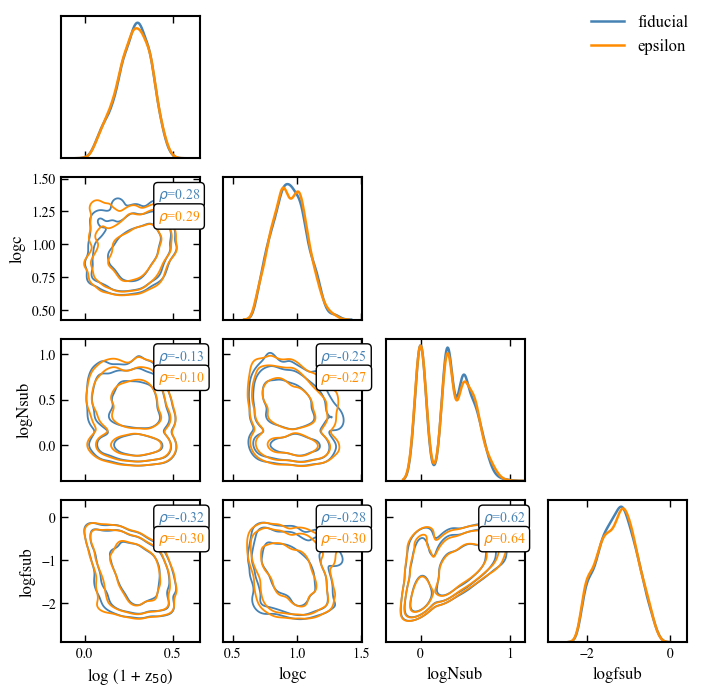

In [10]:
matched = fiducial_df.merge(epsilon_df, on="tree_index", how="inner", suffixes=("_fid", "_eps"))
print(f"{len(matched)} trees matched by tree_index (of {len(fiducial_df)} fiducial / {len(epsilon_df)} epsilon)")

keys = ["log1pz50", "logc", "logNsub", "logfsub"]
paramNames = ["log (1 + z$_{50}$)", "logc", "logNsub", "logfsub"]
models = [("fid", "fiducial"), ("eps", "epsilon")]

fig = plot_corner_with_corr(matched, models=models, keys=keys, paramNames=paramNames,
                             colors=("steelblue", "darkorange"), figsize=double_textwidth)
# fig.savefig("../../figures/epsilon_vs_fiducial_corner.pdf", bbox_inches="tight")  # not auto-saving to disk -- left inline only


<Axes: xlabel='fsub_fid', ylabel='Density'>

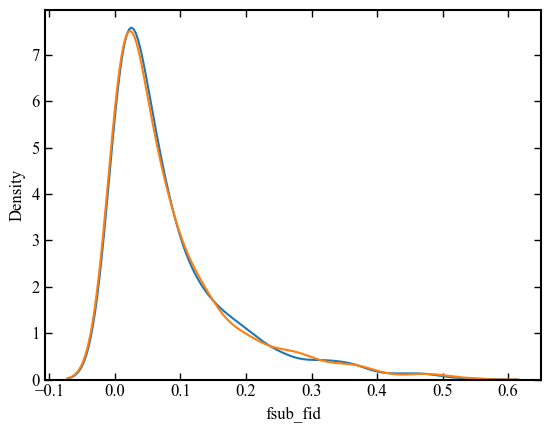

In [8]:
sns.kdeplot(matched["fsub_fid"])
sns.kdeplot(matched["fsub_eps"])